# Alphabet Recognition Using ISL Dataset from Kaggle

In [2]:
import os

extract_path = "/Users/pranav/Desktop/SignBridge/dataset - Gesture Speech"

data_root = None
for root, dirs, files_ in os.walk(extract_path):
    dirs_lower = [d.lower() for d in dirs]
    if 'a' in dirs_lower and 'b' in dirs_lower:
        data_root = root
        break

# Fallback if no subfolder detected
if data_root is None:
    data_root = extract_path

print("Detected data root:", data_root)
print("Classes found:", sorted(os.listdir(data_root)))


Detected data root: /Users/pranav/Desktop/SignBridge/dataset - Gesture Speech
Classes found: ['.DS_Store', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{']


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.16.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 32400 files belonging to 27 classes.
Using 25920 files for training.
Found 32400 files belonging to 27 classes.
Using 6480 files for validation.
Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{']
Num classes: 27


In [5]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Val batches: 102
Test batches: 101


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def prepare(ds, augment=False, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_prepped = prepare(train_ds, augment=True, shuffle=True)
val_ds_prepped = prepare(val_ds)
test_ds_prepped = prepare(test_ds)

In [7]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze base for initial training

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,435 (9.25 MB)

 Trainable params: 167,451 (654.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "./best_model.keras", monitor="val_accuracy", save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)


In [11]:
EPOCHS = 15

history = model.fit(
    train_ds_prepped,
    validation_data=val_ds_prepped,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/15


/Users/pranav/Desktop/SignBridge/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


810/810 ━━━━━━━━━━━━━━━━━━━━ 290s 341ms/step - accuracy: 0.9283 - loss: 0.2197 - val_accuracy: 0.8393 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 2/15
810/810 ━━━━━━━━━━━━━━━━━━━━ 299s 354ms/step - accuracy: 0.9470 - loss: 0.1575 - val_accuracy: 0.8116 - val_loss: 0.7564 - learning_rate: 0.0010
Epoch 3/15
810/810 ━━━━━━━━━━━━━━━━━━━━ 293s 346ms/step - accuracy: 0.9563 - loss: 0.1350 - val_accuracy: 0.8156 - val_loss: 0.7841 - learning_rate: 0.0010
Epoch 4/15
810/810 ━━━━━━━━━━━━━━━━━━━━ 276s 326ms/step - accuracy: 0.9600 - loss: 0.1214 - val_accuracy: 0.8119 - val_loss: 0.8172 - learning_rate: 0.0010
Epoch 5/15
810/810 ━━━━━━━━━━━━━━━━━━━━ 284s 336ms/step - accuracy: 0.9688 - loss: 0.0960 - val_accuracy: 0.7916 - val_loss: 1.0015 - learning_rate: 5.0000e-04
Epoch 6/15
810/810 ━━━━━━━━━━━━━━━━━━━━ 298s 352ms/step - accuracy: 0.9721 - loss: 0.0814 - val_accuracy: 0.8091 - val_loss: 0.8718 - learning_rate: 5.0000e-04


In [12]:
base_model.trainable = True

# Freeze all but the last ~30 layers
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds_prepped,
    validation_data=val_ds_prepped,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 7/25


/Users/pranav/Desktop/SignBridge/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


810/810 ━━━━━━━━━━━━━━━━━━━━ 409s 472ms/step - accuracy: 0.8538 - loss: 0.5575 - val_accuracy: 0.8578 - val_loss: 0.5199 - learning_rate: 1.0000e-05
Epoch 8/25
810/810 ━━━━━━━━━━━━━━━━━━━━ 400s 476ms/step - accuracy: 0.9535 - loss: 0.1405 - val_accuracy: 0.8719 - val_loss: 0.4159 - learning_rate: 1.0000e-05
Epoch 9/25
810/810 ━━━━━━━━━━━━━━━━━━━━ 387s 460ms/step - accuracy: 0.9743 - loss: 0.0755 - val_accuracy: 0.8824 - val_loss: 0.3881 - learning_rate: 1.0000e-05
Epoch 10/25
810/810 ━━━━━━━━━━━━━━━━━━━━ 399s 474ms/step - accuracy: 0.9815 - loss: 0.0534 - val_accuracy: 0.8929 - val_loss: 0.3670 - learning_rate: 1.0000e-05
Epoch 11/25
810/810 ━━━━━━━━━━━━━━━━━━━━ 339s 400ms/step - accuracy: 0.9868 - loss: 0.0377 - val_accuracy: 0.8972 - val_loss: 0.3505 - learning_rate: 1.0000e-05
Epoch 12/25
810/810 ━━━━━━━━━━━━━━━━━━━━ 282s 333ms/step - accuracy: 0.9899 - loss: 0.0296 - val_accuracy: 0.9039 - val_loss: 0.3277 - learning_rate: 1.0000e-05
Epoch 13/25
810/810 ━━━━━━━━━━━━━━━━━━━━ 231s 27

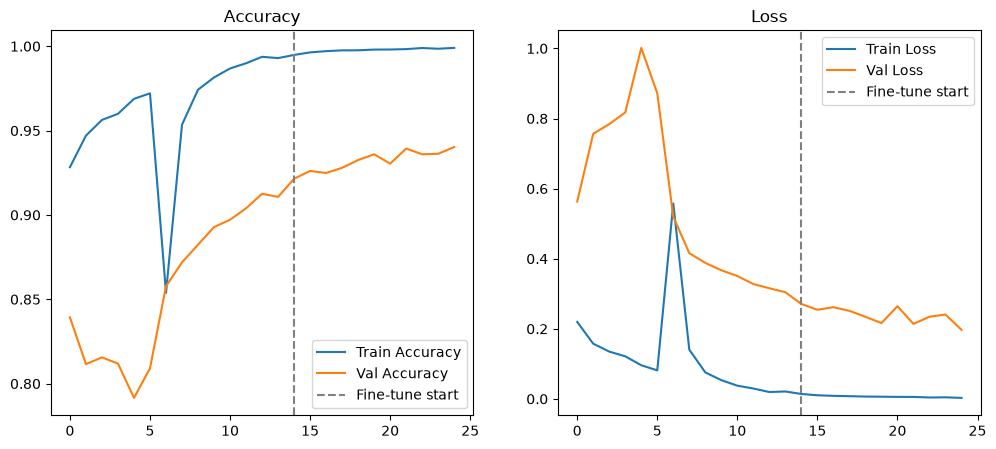

In [13]:
def combine_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_histories(history, history_fine, "accuracy")
val_acc = combine_histories(history, history_fine, "val_accuracy")
loss = combine_histories(history, history_fine, "loss")
val_loss = combine_histories(history, history_fine, "val_loss")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.axvline(EPOCHS - 1, color="gray", linestyle="--", label="Fine-tune start")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.axvline(EPOCHS - 1, color="gray", linestyle="--", label="Fine-tune start")
plt.legend(); plt.title("Loss")
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_ds_prepped)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.9356 - loss: 0.2338
Test Accuracy: 93.56%
Test Loss: 0.2338


2026-08-02 18:06:41.178547: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


              precision    recall  f1-score   support

           a       0.88      1.00      0.94       121
           b       0.98      1.00      0.99       121
           c       0.98      0.98      0.98       103
           d       0.91      0.99      0.95       120
           e       1.00      0.96      0.98       130
           f       1.00      0.90      0.95       114
           g       1.00      0.93      0.96       100
           h       0.92      0.98      0.95        87
           i       0.94      0.94      0.94       124
           j       0.99      0.87      0.93       133
           k       1.00      0.99      1.00       122
           l       0.94      1.00      0.97       117
           m       0.72      0.98      0.83       112
           n       1.00      0.57      0.73       119
           o       0.99      0.97      0.98       108
           p       0.95      0.99      0.97       133
           q       0.82      0.95      0.88       144
           r       0.97    

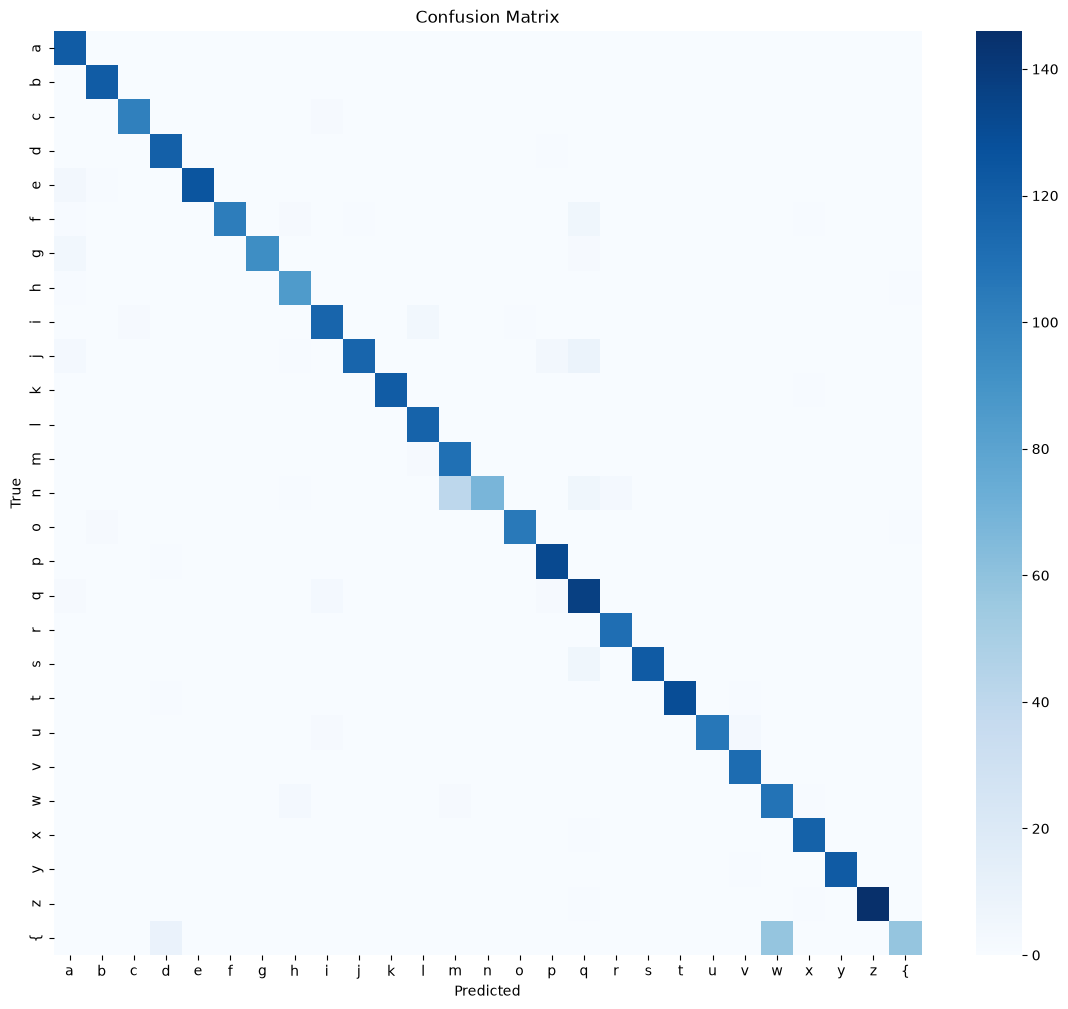

In [15]:
y_true = []
y_pred = []

for images, labels in test_ds_prepped:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [17]:
model.save("./signbridge_mobilenetv2.keras")

In [18]:
from tensorflow.keras.preprocessing import image

def predict_sign(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)
    idx = np.argmax(preds)
    confidence = float(np.max(preds)) * 100
    return {"alphabet": class_names[idx].upper(), "confidence": round(confidence, 2)}

In [27]:
predict_sign("/Users/pranav/Desktop/SignBridge/image3.jpg")

{'alphabet': 'M', 'confidence': 98.42}

In [32]:
def predict_sign_debug(img_path, top_k=5):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(image.img_to_array(img), axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]
    top_idx = np.argsort(preds)[::-1][:top_k]
    for i in top_idx:
        print(f"{class_names[i]}: {preds[i]*100:.2f}%")

predict_sign_debug("/Users/pranav/Desktop/SignBridge/image.png")
predict_sign_debug("/Users/pranav/Desktop/SignBridge/image3.jpg")

m: 99.65%
n: 0.24%
v: 0.06%
h: 0.02%
p: 0.01%
m: 98.42%
v: 0.97%
n: 0.29%
k: 0.11%
w: 0.10%


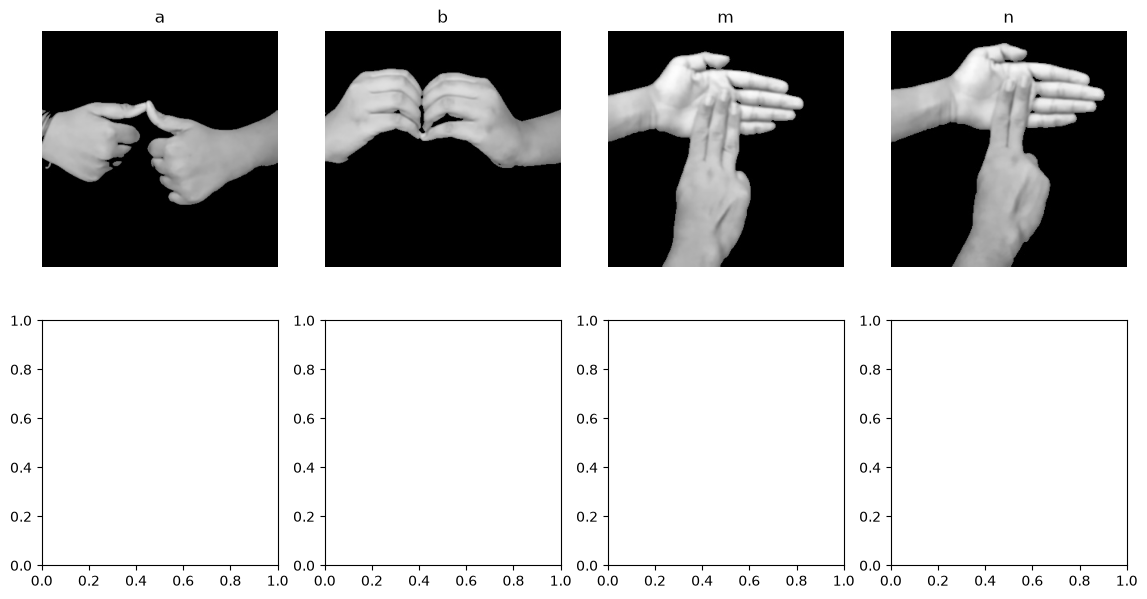

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, letter in enumerate(['a', 'b', 'm', 'n']):
    sample = os.listdir(os.path.join(data_root, letter))[0]
    img = image.load_img(os.path.join(data_root, letter, sample))
    axes[0, i].imshow(img); axes[0, i].set_title(letter); axes[0, i].axis("off")
plt.show()

In [11]:
import mediapipe as mp
import cv2
import numpy as np
import os

mp_hands = mp.solutions.hands

def test_detection_sample(data_root, n_per_class=5):
    results_summary = {}
    with mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.3) as hands:
        for letter in sorted(os.listdir(data_root)):
            class_dir = os.path.join(data_root, letter)
            if not os.path.isdir(class_dir):
                continue
            files = os.listdir(class_dir)[:n_per_class]
            two_hand_count = 0
            for f in files:
                img = cv2.imread(os.path.join(class_dir, f))
                if img is None:
                    continue
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                res = hands.process(img_rgb)
                n_hands = len(res.multi_hand_landmarks) if res.multi_hand_landmarks else 0
                if n_hands == 2:
                    two_hand_count += 1
            results_summary[letter] = f"{two_hand_count}/{len(files)}"
    return results_summary

print(test_detection_sample(data_root, n_per_class=5))

I0000 00:00:1785676974.876944 9182941 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1785676974.896486 9185420 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785676974.908865 9185424 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785676974.951360 9185423 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


{'a': '2/5', 'b': '4/5', 'c': '0/5', 'd': '2/5', 'e': '3/5', 'f': '1/5', 'g': '0/5', 'h': '0/5', 'i': '0/5', 'j': '2/5', 'k': '3/5', 'l': '0/5', 'm': '1/5', 'n': '0/5', 'o': '0/5', 'p': '0/5', 'q': '1/5', 'r': '0/5', 's': '0/5', 't': '5/5', 'u': '0/5', 'v': '0/5', 'w': '1/5', 'x': '0/5', 'y': '3/5', 'z': '1/5', '{': '0/5'}


In [14]:
import mediapipe as mp
import cv2
import numpy as np
import os
from tqdm import tqdm

mp_hands = mp.solutions.hands

def extract_two_hand_landmarks(img_rgb, hands_detector):
    res = hands_detector.process(img_rgb)
    if not res.multi_hand_landmarks or not res.multi_handedness:
        return None

    hands_dict = {}
    for lm, handedness in zip(res.multi_hand_landmarks, res.multi_handedness):
        label = handedness.classification[0].label  # "Left" or "Right"
        coords = np.array([[p.x, p.y, p.z] for p in lm.landmark])

        wrist = coords[0]
        coords = coords - wrist
        scale = np.linalg.norm(coords[9]) + 1e-6
        coords = coords / scale

        hands_dict[label] = coords.flatten()  # 21*3 = 63 values

    left = hands_dict.get("Left", np.zeros(63))
    right = hands_dict.get("Right", np.zeros(63))
    return np.concatenate([left, right])  # 126-dim feature vector

def build_landmark_dataset(data_root, save_every=2000, out_file="landmark_dataset.npz"):
    X, y, skipped = [], [], 0
    class_names = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])

    all_files = []
    for letter in class_names:
        class_dir = os.path.join(data_root, letter)
        for fname in os.listdir(class_dir):
            all_files.append((letter, os.path.join(class_dir, fname)))

    with mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.3) as hands:
        for i, (letter, fpath) in enumerate(tqdm(all_files, desc="Extracting landmarks")):
            img = cv2.imread(fpath)
            if img is None:
                skipped += 1
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            feat = extract_two_hand_landmarks(img_rgb, hands)
            if feat is None:
                skipped += 1
                continue
            X.append(feat)
            y.append(letter)

            if (i + 1) % save_every == 0:
                np.savez(out_file, X=np.array(X), y=np.array(y), class_names=class_names)

    np.savez(out_file, X=np.array(X), y=np.array(y), class_names=class_names)
    print(f"Done. Extracted {len(X)} samples, skipped {skipped}")
    return np.array(X), np.array(y), class_names

X, y_labels, class_names = build_landmark_dataset(data_root)

I0000 00:00:1785677078.464732 9182941 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
Extracting landmarks:   0%|          | 0/32400 [00:00<?, ?it/s]W0000 00:00:1785677078.486230 9186762 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785677078.505391 9186762 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Extracting landmarks: 100%|██████████| 32400/32400 [25:01<00:00, 21.58it/s]


Done. Extracted 26928 samples, skipped 5472


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load if starting fresh in a new session
data = np.load("landmark_dataset.npz", allow_pickle=True)
X, y_labels, class_names = data["X"], data["y"], data["class_names"]

le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)
num_classes = len(le.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Classes:", list(le.classes_))

Train: (18849, 126)  Val: (4039, 126)  Test: (4040, 126)
Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [16]:
from tensorflow.keras import layers, models, callbacks

landmark_model = models.Sequential([
    layers.Input(shape=(126,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

landmark_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

landmark_model.summary()

early_stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint("./best_landmark_model.keras", monitor="val_accuracy", save_best_only=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

history = landmark_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        32,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,298 (274.60 KB)

 Trainable params: 69,530 (271.60 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.6106 - loss: 1.3649 - val_accuracy: 0.8151 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 2/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.7506 - loss: 0.8750 - val_accuracy: 0.8282 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 3/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7817 - loss: 0.7610 - val_accuracy: 0.8581 - val_loss: 0.5185 - learning_rate: 0.0010
Epoch 4/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.7943 - loss: 0.7044 - val_accuracy: 0.8698 - val_loss: 0.4717 - learning_rate: 0.0010
Epoch 5/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.8069 - loss: 0.6660 - val_accuracy: 0.8883 - val_loss: 0.4463 - learning_rate: 0.0010
Epoch 6/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.8130 - loss: 0.6394 - val_accuracy: 0.8779 - val_loss: 0.4435 - learning_rate: 0.0010
Epoch 7/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.8

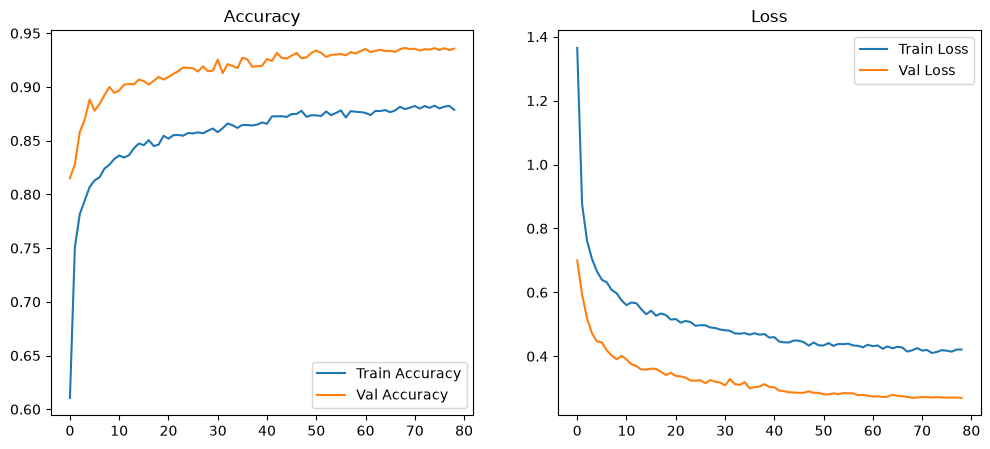

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss")
plt.show()

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9319 - loss: 0.2554
Test Accuracy: 93.19%
Test Loss: 0.2554
              precision    recall  f1-score   support

           a       0.99      0.99      0.99       170
           b       0.94      0.91      0.92       159
           c       0.89      0.91      0.90       159
           d       1.00      0.87      0.93       142
           e       0.91      0.97      0.94       195
           f       0.95      0.92      0.93       166
           g       0.97      0.96      0.97       139
           h       0.93      0.89      0.91       122
           i       0.92      0.97      0.94       172
           j       0.99      0.98      0.99       169
           k       0.96      0.91      0.93       166
           l       0.98      0.97      0.98       182
           m       0.85      0.89      0.87       143
           n       0.72      0.75      0.74       151
           o       0.82      0.93      0.87       183
           p       

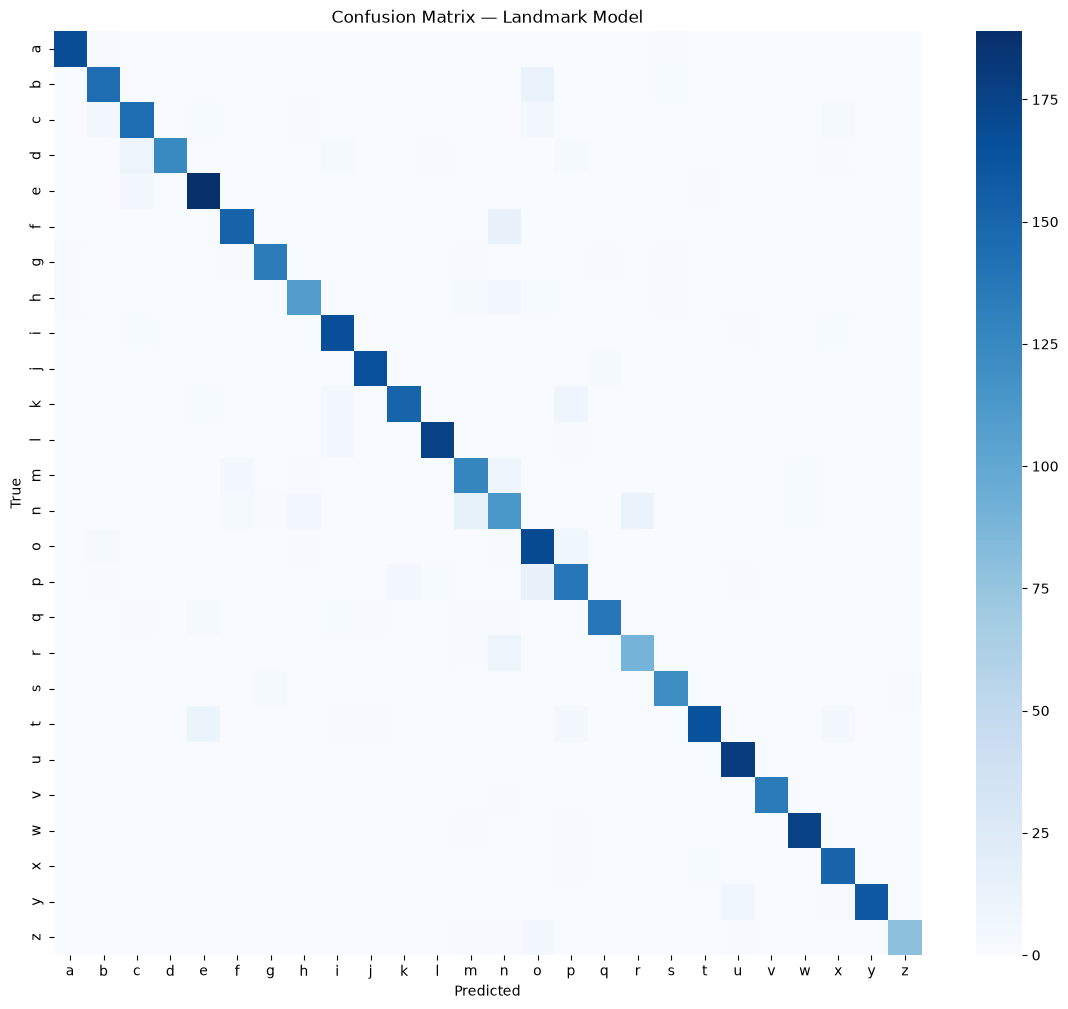

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = landmark_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = landmark_model.predict(X_test, verbose=0)
y_true_idx = np.argmax(y_test, axis=1)
y_pred_idx = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true_idx, y_pred_idx, target_names=le.classes_))

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Landmark Model")
plt.show()

In [19]:
landmark_model.save("./signbridge_landmark_model.keras")
np.save("./label_classes.npy", le.classes_)
print("Saved model and label classes.")

Saved model and label classes.


In [23]:
CONFIDENCE_THRESHOLD = 60  # tune after seeing real results

def predict_sign_landmarks(img_path, hands_detector=None):
    img = cv2.imread(img_path)
    if img is None:
        return {"error": f"Could not read image: {img_path}"}
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    close_after = False
    if hands_detector is None:
        hands_detector = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.3)
        close_after = True

    feat = extract_two_hand_landmarks(img_rgb, hands_detector)
    if close_after:
        hands_detector.close()

    if feat is None:
        return {"error": "No hand(s) detected in image"}

    preds = landmark_model.predict(feat.reshape(1, -1), verbose=0)[0]
    idx = np.argmax(preds)
    confidence = round(float(preds[idx]) * 100, 2)
    label = le.classes_[idx]

    if confidence < CONFIDENCE_THRESHOLD:
        return {"alphabet": "Unknown", "confidence": confidence, "raw_top_guess": label.upper()}

    return {"alphabet": label.upper(), "confidence": confidence}


predict_sign_landmarks("/Users/pranav/Desktop/SignBridge/image.png")
predict_sign_landmarks("/Users/pranav/Desktop/SignBridge/image2.png")

I0000 00:00:1785684501.422793 9182941 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1785684501.441724 9253582 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785684501.456175 9253588 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1785684501.636767 9182941 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1785684501.650523 9253614 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785684501.659524 9253615 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


{'alphabet': 'Unknown', 'confidence': 40.37, 'raw_top_guess': 'H'}